# DOWNLOAD SWOT RASTERS

In this notebook we will create the SWOT mosaics using the SWOT Toolkit developed previously.

In [1]:
%load_ext autoreload
%autoreload 2

import earthaccess
import geopandas as gpd

from swot_toolkit.kml import read_kml_geometry
from swot_toolkit.swot import (
    adjust_footprint_signs,
    auth_earthaccess,
    create_mosaic_df,
    get_swot_footprint,
    open_pixc_file,
    search_swot_data,
    swot_results_to_df,
)


/workspaces/swot/.venv/lib/python3.12/site-packages/fastkml/config.py:39: UserWarning: Package `lxml` missing. Pretty print will be disabled
  warnings.warn("Package `lxml` missing. Pretty print will be disabled")  # noqa: B028


In [2]:
auth_earthaccess()

# Open the AOI

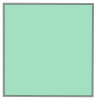

In [3]:
# Read geometry from a KML file
aois = read_kml_geometry("/data/swot/AOIs/Curua-Una.kml")
if aois is not None:
    aoi = aois[0]

aoi

## Search for SWOT Rasters

In [4]:
# Search for products within the AOI and Time frame
results = search_swot_data(
    dataset="Raster_100",
    date_range=("2024-01-01", "2025-11-30"),
    aoi=aoi,
    footprint_filter=True,  # Apply footprint filter to ensure granules intersect with AOI
)

len(results)

48

In [5]:
swot_df = swot_results_to_df(results, drop_duplicates=True)
len(swot_df)

44

In [6]:
mosaic_df = create_mosaic_df(swot_df, max_delta=30)
mosaic_df

cycle_id pass_id tile_id         date_str  vers  \
mosaic_date tile_name                                                   
2024-01-08  033_075F       009     033    075F  20240105T072529  PIC0   
            186_080F       009     186    080F  20240110T183829  PIC0   
2024-01-28  033_075F       010     033    075F  20240126T041035  PIC0   
            186_080F       010     186    080F  20240131T152335  PIC0   
2024-02-18  033_075F       011     033    075F  20240216T005540  PIC0   
            186_080F       011     186    080F  20240221T120840  PIC0   
2024-03-10  033_075F       012     033    075F  20240307T214044  PIC0   
            186_080F       012     186    080F  20240313T085342  PIC0   
2024-03-31  033_075F       013     033    075F  20240328T182548  PIC0   
            186_080F       013     186    080F  20240403T053847  PIC0   
2024-04-21  033_075F       014     033    075F  20240418T151054  PIC0   
            186_080F       014     186    080F  20240424T022353  PIC0   
2024-05-12  033_075F       015     033    075F  20240509T115557  PIC0   
            186_080F       015     186    080F  20240514T230857  PIC0   
2024-06-02  033_075F       016     033    075F  20240530T084102  PIC0   
            186_080F       016     186    080F  20240604T195403  PIC0   
2024-06-22  033_075F       017     033    075F  20240620T052607  PIC0   
            186_080F       017     186    080F  20240625T163906  PIC0   
2024-07-13  033_075F       018     033    075F  20240711T021110  PIC0   
            186_080F       018     186    080F  20240716T132411  PIC0   
2024-08-24  033_075F       020     033    075F  20240821T194119  PIC0   
            186_080F       020     186    080F  20240827T065419  PIC0   
2024-09-14  033_075F       021     033    075F  20240911T162625  PIC0   
            186_080F       021     186    080F  20240917T033926  PIC0   
2024-09-24  033_075F       022     033    075F  20241002T131134  PIC0   
            186_080F       021     186    080F  20240917T033926  PIC0   
2024-10-26  033_075F       023     033    075F  20241023T095637  PIC2   
            186_080F       023     186    080F  20241028T210936  PIC2   
2024-12-06  033_075F       025     033    075F  20241204T032646  PIC2   
            186_080F       025     186    080F  20241209T143946  PIC2   
2024-12-27  033_075F       026     033    075F  20241225T001150  PIC2   
            186_080F       026     186    080F  20241230T112450  PIC2   
2025-01-17  033_075F       027     033    075F  20250114T205654  PIC2   
            186_080F       027     186    080F  20250120T080955  PIC2   
2025-02-07  033_075F       028     033    075F  20250204T174158  PIC2   
            186_080F       028     186    080F  20250210T045458  PIC2   
2025-02-28  033_075F       029     033    075F  20250225T142704  PIC2   
            186_080F       029     186    080F  20250303T014003  PIC2   
2025-03-21  033_075F       030     033    075F  20250318T111209  PIC2   
            186_080F       030     186    080F  20250323T222508  PIC2   
2025-04-11  033_075F       031     033    075F  20250408T075712  PIC2   
            186_080F       031     186    080F  20250413T191013  PIC2   
2025-04-21  033_075F       032     033    075F  20250429T044218  PIC2   
            186_080F       031     186    080F  20250413T191013  PIC2   

                                                                    item  \
mosaic_date tile_name                                                      
2024-01-08  033_075F   {'meta': {'concept-type': 'granule', 'concept-...   
            186_080F   {'meta': {'concept-type': 'granule', 'concept-...   
2024-01-28  033_075F   {'meta': {'concept-type': 'granule', 'concept-...   
            186_080F   {'meta': {'concept-type': 'granule', 'concept-...   
2024-02-18  033_075F   {'meta': {'concept-type': 'granule', 'concept-...   
            186_080F   {'meta': {'concept-type': 'granule', 'concept-...   
2024-03-10  033_075F   {'meta': {'concept-type': 'granu

In [7]:
mosaic_df.loc["2024-01-08"]

,cycle_id,pass_id,tile_id,date_str,vers,item,datetime,date,delta
tile_name,,,,,,,,,
033_075F,009,033,075F,20240105T072529,PIC0,"{'meta': {'concept-type': 'granule', 'concept-...",2024-01-05 07:25:29,2024-01-05,0 days 00:00:00
186_080F,009,186,080F,20240110T183829,PIC0,"{'meta': {'concept-type': 'granule', 'concept-...",2024-01-10 18:38:29,2024-01-10,5 days 11:13:00


<Axes: >

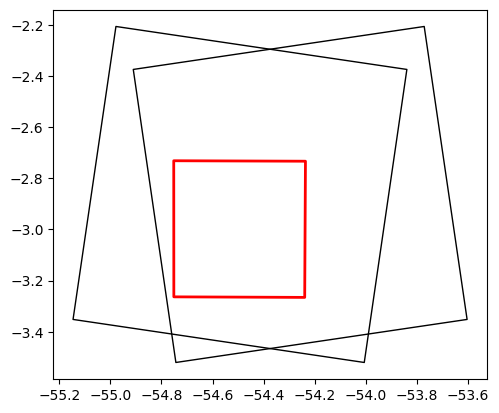

In [8]:
# Plot footprints vs AOI
# Create a DF for the AOI
aoi_df = gpd.GeoDataFrame(geometry=[aoi], crs="EPSG:4326")

mosaic = mosaic_df.loc["2024-01-08"]
footprints = [get_swot_footprint(item)[0] for item in mosaic["item"]]

footprints_df = gpd.GeoDataFrame(geometry=footprints, crs="EPSG:4326")
ax = aoi_df.plot(color="none", edgecolor="red", linewidth=2)
footprints_df.plot(ax=ax, color="none")

## Download single raster

In [9]:
import numpy as np
import rioxarray as xrio

In [10]:
raster_item = mosaic["item"].iloc[0]
raster_item

Collection: {'Version': '2.0', 'ShortName': 'SWOT_L2_HR_Raster_2.0'}
Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'GPolygons': [{'Boundary': {'Points': [{'Latitude': -3.519923595260316, 'Longitude': -55.14578554225298}, {'Latitude': -3.519923595260316, 'Longitude': -53.83938029472503}, {'Latitude': -2.2066260584520814, 'Longitude': -53.83938029472503}, {'Latitude': -2.2066260584520814, 'Longitude': -55.14578554225298}, {'Latitude': -3.519923595260316, 'Longitude': -55.14578554225298}]}}]}, 'Track': {'Cycle': 9, 'Passes': [{'Pass': 33, 'Tiles': ['148L', '149L', '150L', '151L', '148R', '149R', '150R', '151R']}]}}}
Temporal coverage: {'RangeDateTime': {'EndingDateTime': '2024-01-05T07:25:50.895Z', 'BeginningDateTime': '2024-01-05T07:25:29.809Z'}}
Size(MB): 33.4339485168457
Data: ['https://archive.swot.podaac.earthdata.nasa.gov/podaac-swot-ops-cumulus-protected/SWOT_L2_HR_Raster_2.0/SWOT_L2_HR_Raster_100m_UTM21M_N_x_x_x_009_033_075F_20240105T072529_20240105T072550_PIC0_01.nc']

In [11]:
raster_file = earthaccess.download([raster_item], local_path="/data/swot/downloads")
raster_file

QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

['/data/swot/downloads/SWOT_L2_HR_Raster_100m_UTM21M_N_x_x_x_009_033_075F_20240105T072529_20240105T072550_PIC0_01.nc']

In [12]:
raster = xrio.open_rasterio(raster_file[0]).squeeze()
raster

<xarray.Dataset> Size: 325MB
Dimensions:                  (x: 1457, y: 1456)
Coordinates:
    band                     int64 8B 1
  * x                        (x) float64 12kB 7.06e+05 7.061e+05 ... 8.516e+05
  * y                        (y) float64 12kB 9.756e+06 9.756e+06 ... 9.61e+06
    crs                      int64 8B 0
    spatial_ref              int64 8B 0
Data variables: (12/38)
    longitude                (y, x) float64 17MB ...
    water_area_uncert        (y, x) float32 8MB ...
    water_frac               (y, x) float32 8MB ...
    water_frac_uncert        (y, x) float32 8MB ...
    sig0                     (y, x) float32 8MB ...
    sig0_qual                (y, x) uint8 2MB ...
    ...                       ...
    wse_qual                 (y, x) uint8 2MB ...
    wse_qual_bitwise         (y, x) uint32 8MB ...
    wse_uncert               (y, x) float32 8MB ...
    water_area               (y, x) float32 8MB ...
    water_area_qual          (y, x) uint8 2MB ...
    water_area_qual_bitwise  (y, x) uint32 8MB ...
Attributes: (12/49)
    contact:                       alexander.t.corben[at]jpl.nasa.gov
    Conventions:                   CF-1.7
    coordinate_reference_system:   Universal Transverse Mercator
    crid:                          PIC0
    cycle_number:                  9
    descriptor_string:             100m_UTM21M_N_x_x_x
    ...                            ...
    xref_param_l2_hr_raster_file:  SWOT_Param_L2_HR_Raster_20000101T000000_21...
    xref_reforbittrack_files:      SWOT_RefOrbitTrackTileBoundary_Nom_2000010...
    x_max:                         851600
    x_min:                         706000
    y_max:                         9755900
    y_min:                         9610400

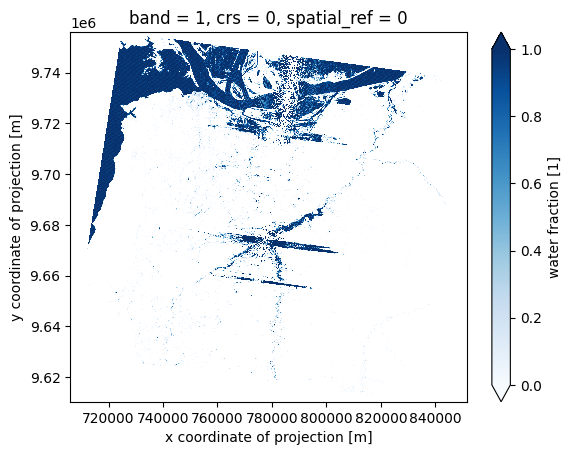

In [13]:
water_frac = raster["water_frac"]
water_frac = water_frac.where(water_frac.attrs["_FillValue"] != water_frac)
water_frac.plot(cmap="Blues", vmin=0, vmax=1)

In [108]:
from swot_toolkit.swot import get_raster_footprint, get_nadir_from_raster
from rasterio.features import geometry_mask

ref_crs = raster["water_frac"].rio.crs
nadir = get_nadir_from_raster(raster, crs=ref_crs)

inner_swath = nadir.buffer(10000, cap_style="flat")

In [112]:
list(nadir.coords)

[(788229.8235542746, 9746542.93662474), (769342.1731233858, 9619871.449031832)]

In [ ]:
ref_array = raster["water_frac"]

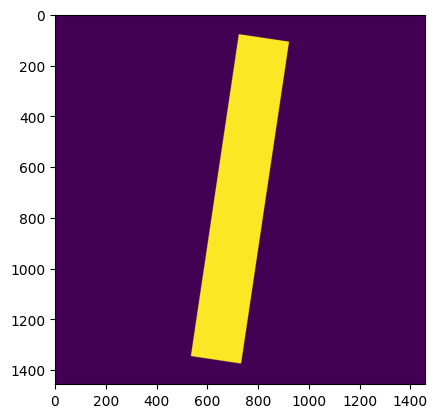

In [88]:
mask = geometry_mask(
    geometries=[inner_swath],
    out_shape=ref_array.shape,
    transform=ref_array.rio.transform(),
    invert=True,
)

plt.imshow(mask)

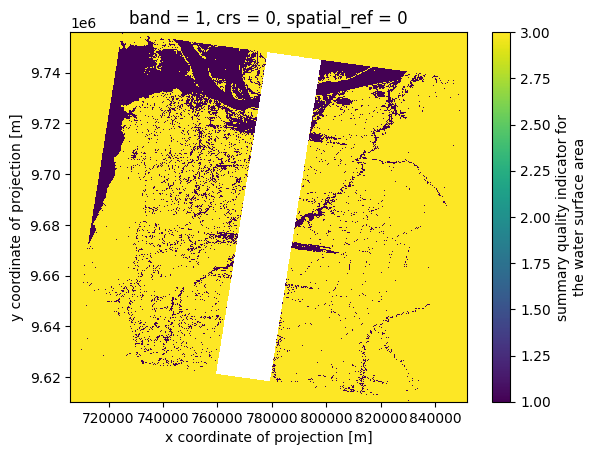

In [90]:
raster["water_area_qual"].where(~mask).plot()

<Axes: title={'center': 'band = 1, crs = 0, spatial_ref = 0'}, xlabel='x coordinate of projection [m]', ylabel='y coordinate of projection [m]'>

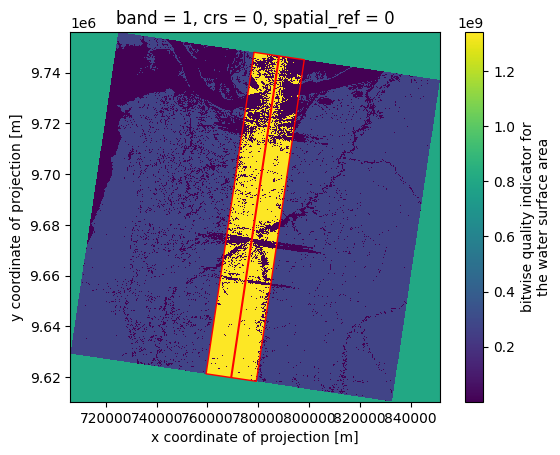

In [79]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
raster["water_area_qual_bitwise"].plot()
nadir_line_gdf.plot(ax=ax, color="red")
nadir_line_gdf.buffer(10000, cap_style="flat").plot(ax=ax, facecolor="none", edgecolor="red")

### Quality Flags

In [94]:
import matplotlib.pyplot as plt

from swot_toolkit.flags import QUALITY_FLAGS, decode_flags, mask_by_flags, select_pixels_by_quality


In [95]:
# Look for specular ringing pixels
flags = raster["water_area_qual_bitwise"]
# flags = flags.where(flags != flags.attrs["_FillValue"])
unique_flags = np.unique(flags.data)
for val in unique_flags.astype("int"):
    print(val, bin(val), decode_flags(val))

6 0b110 ['classification_qual_suspect', 'geolocation_qual_suspect']
14 0b1110 ['classification_qual_suspect', 'geolocation_qual_suspect']
46 0b101110 ['classification_qual_suspect', 'geolocation_qual_suspect', 'large_uncert_suspect']
134 0b10000110 ['classification_qual_suspect', 'geolocation_qual_suspect', 'bright_land']
142 0b10001110 ['classification_qual_suspect', 'geolocation_qual_suspect', 'bright_land']
262 0b100000110 ['classification_qual_suspect', 'geolocation_qual_suspect', 'low_coherence_water_suspect']
270 0b100001110 ['classification_qual_suspect', 'geolocation_qual_suspect', 'low_coherence_water_suspect']
294 0b100100110 ['classification_qual_suspect', 'geolocation_qual_suspect', 'large_uncert_suspect', 'low_coherence_water_suspect']
302 0b100101110 ['classification_qual_suspect', 'geolocation_qual_suspect', 'large_uncert_suspect', 'low_coherence_water_suspect']
390 0b110000110 ['classification_qual_suspect', 'geolocation_qual_suspect', 'bright_land', 'low_coherence_wate

In [104]:
no_data_flags = [
    "outside_scene_bounds",
    "outside_data_window",
    "near_range_suspect",
]

noise_flags = [
    # "near_range_suspect",
    "classification_qual_degraded",
    "value_bad",
    "specular_ringing_prior_water_suspect",
    "specular_ringing_prior_land_suspect",
    "missing_karin_data",
]


In [105]:
no_data_mask = mask_by_flags(flags, no_data_flags)
# no_data_mask = no_data_mask | mask

noise_mask = mask_by_flags(flags, noise_flags)

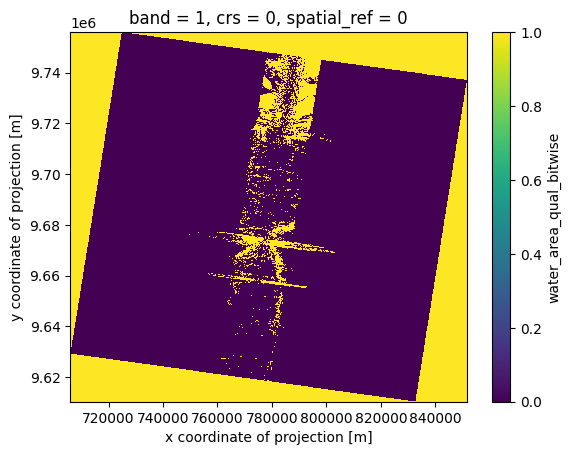

In [106]:
no_data_mask.plot()

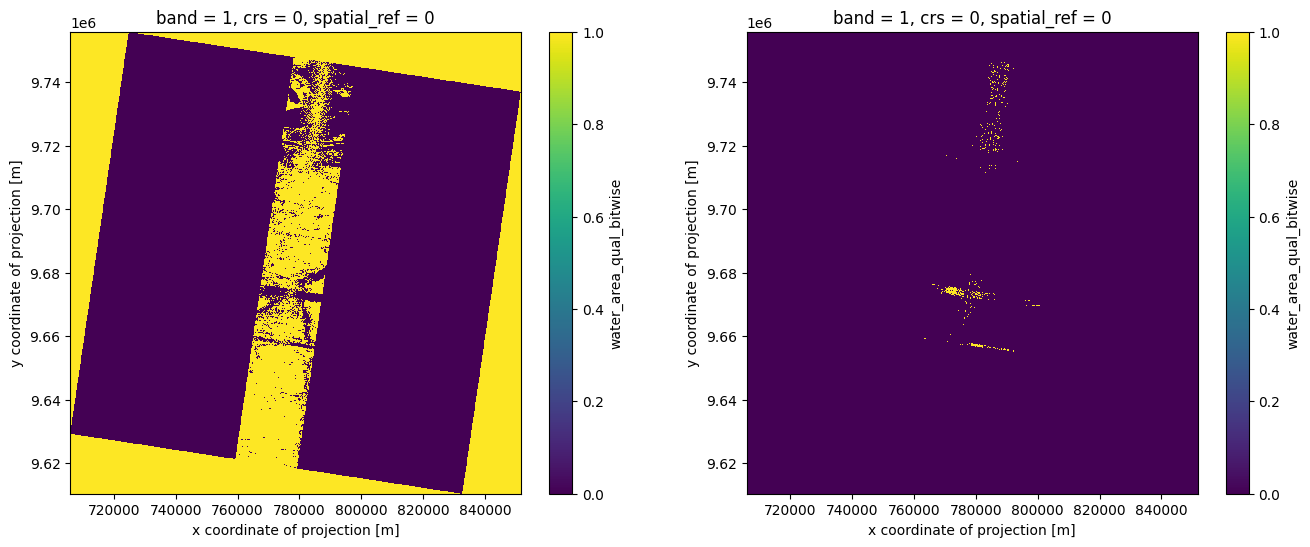

In [61]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6))
axs[0].set_title("No Data Mask")
axs[1].set_title("Noise Mask")
no_data_mask.plot.imshow(ax=axs[0])
noise_mask.plot.imshow(ax=axs[1])

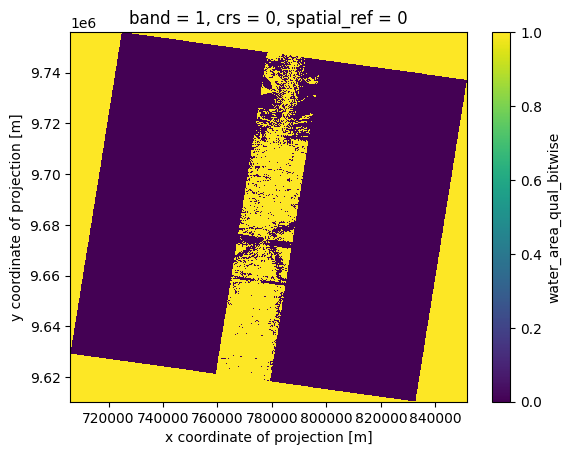

In [33]:
no_data_mask.plot()

In [ ]:
da, mask = select_pixels_by_quality(raster, include_flags=flags_to_select)
da["water_frac"].plot(cmap="Blues", vmin=0, vmax=1)

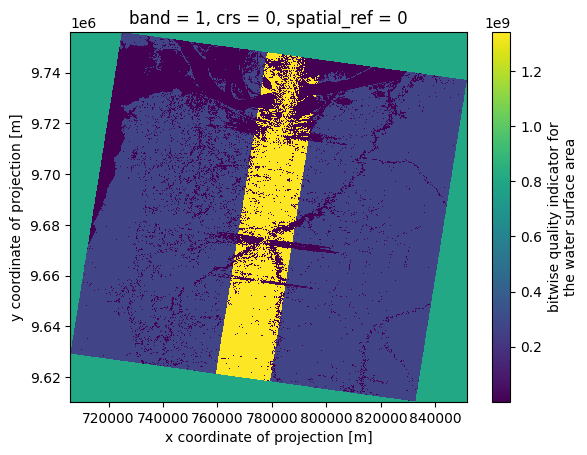

In [236]:
raster["water_area_qual_bitwise"].plot()

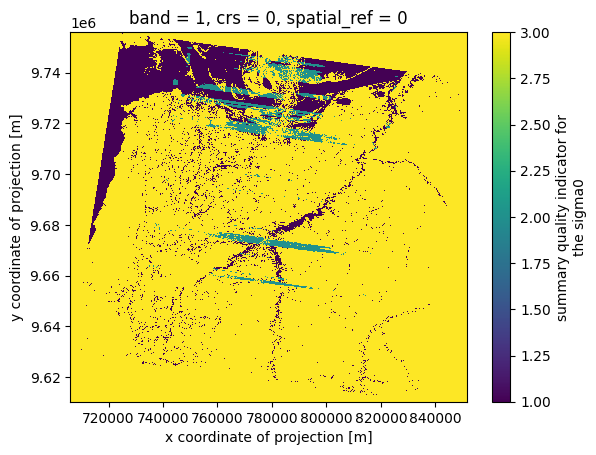

In [287]:
raster["sig0_qual"].plot()

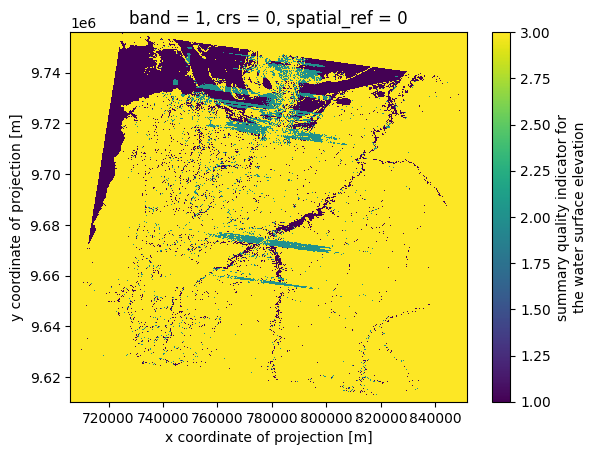

In [286]:
raster["wse_qual"].plot()

In [280]:
water_area_qual = raster["cross_track"]

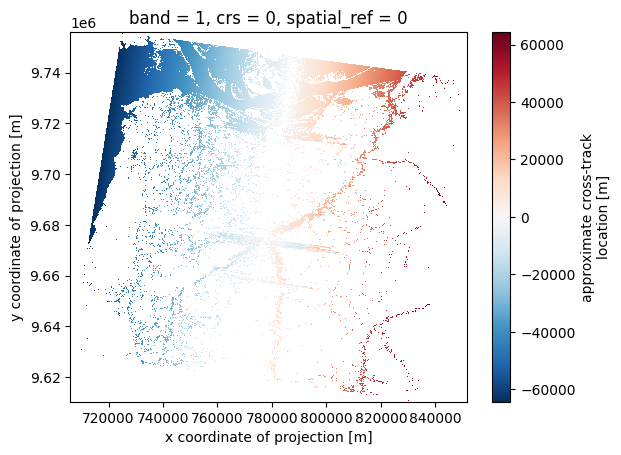

In [285]:
water_area_qual.where(water_area_qual != water_area_qual.attrs["_FillValue"]).plot()

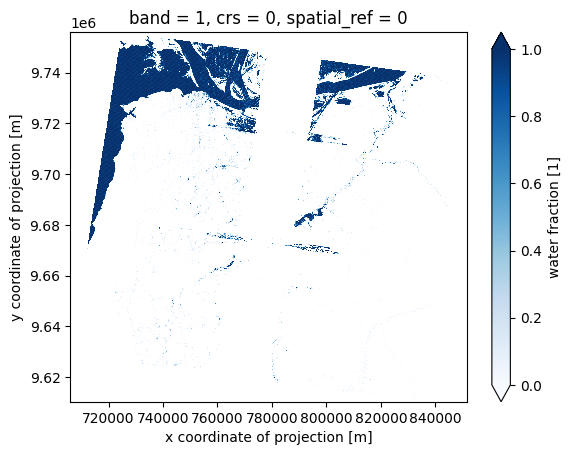

In [289]:
water_frac = raster["water_frac"]
fill_value = water_frac.attrs["_FillValue"]
water_frac = water_frac.where(water_frac != fill_value)

water_frac = water_frac.where(~mask)

water_frac.squeeze().plot.imshow(vmin=0, vmax=1, cmap="Blues")

## Create Raster Mosaic

In [290]:
from swot_toolkit.swot import create_raster_mosaic

In [291]:
array = create_raster_mosaic(
    mosaic_df,
    ref_date="2024-01-08",
    aoi=aoi,
    variable="water_frac",
    local_path="/data/swot/downloads",
    exclude_flags=flags_to_select,
)

/workspaces/swot/.venv/lib/python3.12/site-packages/xarray/core/duck_array_ops.py:251: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)


In [292]:
water_frac = array["water_frac"]
water_frac

<xarray.DataArray 'water_frac' (idx: 2, y: 594, x: 573)> Size: 3MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]],
      shape=(2, 594, 573), dtype=float32)
Coordinates:
    band     int64 8B 1
    crs      int64 8B 0
  * x        (x) float64 5kB -54.75 -54.75 -54.75 ... -54.24 -54.24 -54.24
  * y        (y) float64 5kB -2.731 -2.732 -2.733 ... -3.264 -3.265 -3.266
Dimensions without coordinates: idx
Attributes:
    long_name:     water fraction
    units:         1
    quality_flag:  water_area_qual
    valid_min:     -1000
    valid_max:     10000
    coordinates:   x y
    comment:       Fraction of the pixel that is water.

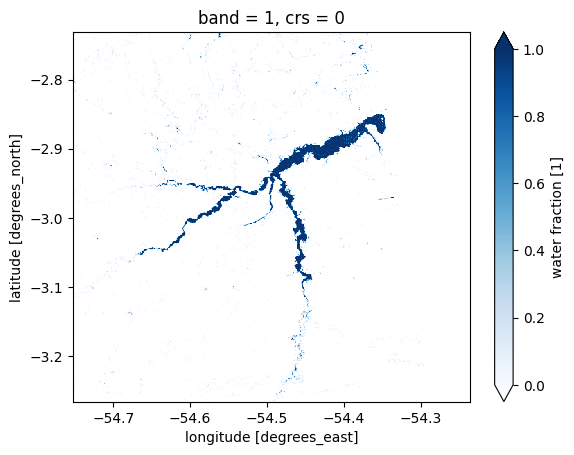

In [293]:
water_frac.sel(idx=1).plot.imshow(cmap="Blues", vmin=0, vmax=1)

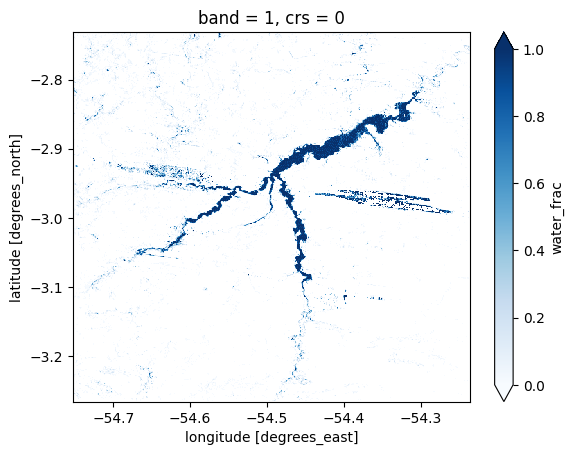

In [294]:
water_frac.mean(dim="idx").plot.imshow(cmap="Blues", vmin=0, vmax=1)

In [278]:
ds

<xarray.Dataset> Size: 416MB
Dimensions:                  (y: 1456, x: 1457)
Coordinates:
  * x                        (x) float64 12kB 7.06e+05 7.061e+05 ... 8.516e+05
  * y                        (y) float64 12kB 9.61e+06 9.61e+06 ... 9.756e+06
Data variables: (12/39)
    crs                      object 8B ...
    longitude                (y, x) float64 17MB ...
    latitude                 (y, x) float64 17MB ...
    wse                      (y, x) float32 8MB ...
    wse_qual                 (y, x) float32 8MB ...
    wse_qual_bitwise         (y, x) float64 17MB ...
    ...                       ...
    load_tide_fes            (y, x) float32 8MB ...
    load_tide_got            (y, x) float32 8MB ...
    pole_tide                (y, x) float32 8MB ...
    model_dry_tropo_cor      (y, x) float32 8MB ...
    model_wet_tropo_cor      (y, x) float32 8MB ...
    iono_cor_gim_ka          (y, x) float32 8MB ...
Attributes: (12/49)
    Conventions:                   CF-1.7
    title:                         Level 2 KaRIn High Rate Raster Data Product
    source:                        Ka-band radar interferometer
    history:                       2024-01-09T08:04:37Z : Creation
    platform:                      SWOT
    references:                    V1.1.1
    ...                            ...
    x_min:                         706000.0
    x_max:                         851600.0
    y_min:                         9610400.0
    y_max:                         9755900.0
    institution:                   CNES
    product_version:               01

In [218]:
array.shape

(2, 594, 573)

In [223]:
array.sel(idx=1)

<xarray.DataArray 'water_frac' (y: 594, x: 573)> Size: 1MB
array([[9.96921e+36, 9.96921e+36, 9.96921e+36, ..., 9.96921e+36,
        9.96921e+36, 9.96921e+36],
       [9.96921e+36, 9.96921e+36, 9.96921e+36, ..., 9.96921e+36,
        9.96921e+36, 9.96921e+36],
       [9.96921e+36, 9.96921e+36, 9.96921e+36, ..., 9.96921e+36,
        9.96921e+36, 9.96921e+36],
       ...,
       [9.96921e+36, 9.96921e+36, 9.96921e+36, ..., 9.96921e+36,
        9.96921e+36, 9.96921e+36],
       [9.96921e+36, 9.96921e+36, 9.96921e+36, ..., 9.96921e+36,
        9.96921e+36, 9.96921e+36],
       [9.96921e+36, 9.96921e+36, 9.96921e+36, ..., 9.96921e+36,
        9.96921e+36, 9.96921e+36]], shape=(594, 573), dtype=float32)
Coordinates:
    band     int64 8B 1
    crs      int64 8B 0
  * x        (x) float64 5kB -54.75 -54.75 -54.75 ... -54.24 -54.24 -54.24
  * y        (y) float64 5kB -2.731 -2.732 -2.733 ... -3.264 -3.265 -3.266
Attributes:
    long_name:     water fraction
    units:         1
    quality_flag:  water_area_qual
    valid_min:     -1000
    valid_max:     10000
    coordinates:   x y
    comment:       Fraction of the pixel that is water.
    scale_factor:  1.0
    add_offset:    0.0
    _FillValue:    9.96921e+36

In [211]:
array[0].rio.reproject_match?

Signature:
array[0].rio.reproject_match(
    match_data_array: Union[xarray.core.dataarray.DataArray, xarray.core.dataset.Dataset],
    *,
    resampling: rasterio.enums.Resampling = <Resampling.nearest: 0>,
    **reproject_kwargs,
) -> xarray.core.dataarray.DataArray
Docstring:
Reproject a DataArray object to match the resolution, projection,
and region of another DataArray.

Powered by :func:`rasterio.warp.reproject`

.. note:: Only 2D/3D arrays with dimensions 'x'/'y' are currently supported.
    Requires either a grid mapping variable with 'spatial_ref' or
    a 'crs' attribute to be set containing a valid CRS.
    If using a WKT (e.g. from spatiareference.org), make sure it is an OGC WKT.

.. versionadded:: 0.9 reproject_kwargs

Parameters
----------
match_data_array:  :obj:`xarray.DataArray` | :obj:`xarray.Dataset`
    DataArray of the target resolution and projection.
resampling: rasterio.enums.Resampling, optional
    See :func:`rasterio.warp.reproject` for more details.
**repr

In [212]:
array[1] = array[1].rio.reproject_match(array[0])

In [213]:
xr.concat(array, dim="time")

<xarray.DataArray 'water_frac' (time: 2, band: 1, y: 594, x: 573)> Size: 3MB
array([[[[9.96921e+36, 9.96921e+36, 9.96921e+36, ..., 9.96921e+36,
          9.96921e+36, 9.96921e+36],
         [9.96921e+36, 9.96921e+36, 9.96921e+36, ..., 9.96921e+36,
          9.96921e+36, 9.96921e+36],
         [9.96921e+36, 9.96921e+36, 9.96921e+36, ..., 9.96921e+36,
          9.96921e+36, 9.96921e+36],
         ...,
         [9.96921e+36, 9.96921e+36, 9.96921e+36, ..., 9.96921e+36,
          9.96921e+36, 9.96921e+36],
         [9.96921e+36, 9.96921e+36, 9.96921e+36, ..., 9.96921e+36,
          9.96921e+36, 9.96921e+36],
         [9.96921e+36, 9.96921e+36, 9.96921e+36, ..., 9.96921e+36,
          9.96921e+36, 9.96921e+36]]],


       [[[9.96921e+36, 9.96921e+36, 9.96921e+36, ..., 9.96921e+36,
          9.96921e+36, 9.96921e+36],
         [9.96921e+36, 9.96921e+36, 9.96921e+36, ..., 9.96921e+36,
          9.96921e+36, 9.96921e+36],
         [9.96921e+36, 9.96921e+36, 9.96921e+36, ..., 9.96921e+36,
          9.96921e+36, 9.96921e+36],
         ...,
         [9.96921e+36, 9.96921e+36, 9.96921e+36, ..., 9.96921e+36,
          9.96921e+36, 9.96921e+36],
         [9.96921e+36, 9.96921e+36, 9.96921e+36, ..., 9.96921e+36,
          9.96921e+36, 9.96921e+36],
         [9.96921e+36, 9.96921e+36, 9.96921e+36, ..., 9.96921e+36,
          9.96921e+36, 9.96921e+36]]]],
      shape=(2, 1, 594, 573), dtype=float32)
Coordinates:
  * x            (x) float64 5kB -54.75 -54.75 -54.75 ... -54.24 -54.24 -54.24
  * y            (y) float64 5kB -2.731 -2.732 -2.733 ... -3.264 -3.265 -3.266
  * band         (band) int64 8B 1
    spatial_ref  int64 8B 0
    crs          int64 8B 0
Dimensions without coordinates: time
Attributes:
    long_name:     water fraction
    units:         1
    quality_flag:  water_area_qual
    valid_min:     -1000
    valid_max:     10000
    coordinates:   x y
    comment:       Fraction of the pixel that is water.
    scale_factor:  1.0
    add_offset:    0.0
    _FillValue:    9.96921e+36

In [146]:
mosaic_items = mosaic_df.loc["2024-01-08"]

In [148]:
items = mosaic_items["item"].to_list()

In [ ]:
mosaic_files = earthaccess.download(
    items,
    local_path="/data/swot/downloads",
    pqdm_kwargs={"disable": True},
)

In [152]:
mosaic_files[0]

'/data/swot/downloads/SWOT_L2_HR_Raster_100m_UTM21M_N_x_x_x_009_033_075F_20240105T072529_20240105T072550_PIC0_01.nc'

In [155]:
patches = [xr.open_dataset(f) for f in mosaic_files]

In [166]:
patches[0]

<xarray.Dataset> Size: 416MB
Dimensions:                  (y: 1456, x: 1457)
Coordinates:
  * x                        (x) float64 12kB 7.06e+05 7.061e+05 ... 8.516e+05
  * y                        (y) float64 12kB 9.61e+06 9.61e+06 ... 9.756e+06
Data variables: (12/39)
    crs                      object 8B ...
    longitude                (y, x) float64 17MB ...
    latitude                 (y, x) float64 17MB ...
    wse                      (y, x) float32 8MB ...
    wse_qual                 (y, x) float32 8MB ...
    wse_qual_bitwise         (y, x) float64 17MB ...
    ...                       ...
    load_tide_fes            (y, x) float32 8MB ...
    load_tide_got            (y, x) float32 8MB ...
    pole_tide                (y, x) float32 8MB ...
    model_dry_tropo_cor      (y, x) float32 8MB ...
    model_wet_tropo_cor      (y, x) float32 8MB ...
    iono_cor_gim_ka          (y, x) float32 8MB ...
Attributes: (12/49)
    Conventions:                   CF-1.7
    title:                         Level 2 KaRIn High Rate Raster Data Product
    source:                        Ka-band radar interferometer
    history:                       2024-01-09T08:04:37Z : Creation
    platform:                      SWOT
    references:                    V1.1.1
    ...                            ...
    x_min:                         706000.0
    x_max:                         851600.0
    y_min:                         9610400.0
    y_max:                         9755900.0
    institution:                   CNES
    product_version:               01

In [168]:
import rioxarray as xrio

In [170]:
gds = xrio.open_rasterio(mosaic_files[0])

In [179]:
gds = gds["water_frac"]

In [181]:
gds.rio.reproject("EPSG:4326")

<xarray.DataArray 'water_frac' (band: 1, y: 1463, x: 1456)> Size: 9MB
array([[[9.96921e+36, 9.96921e+36, 9.96921e+36, ..., 9.96921e+36,
         9.96921e+36, 9.96921e+36],
        [9.96921e+36, 9.96921e+36, 9.96921e+36, ..., 9.96921e+36,
         9.96921e+36, 9.96921e+36],
        [9.96921e+36, 9.96921e+36, 9.96921e+36, ..., 9.96921e+36,
         9.96921e+36, 9.96921e+36],
        ...,
        [9.96921e+36, 9.96921e+36, 9.96921e+36, ..., 9.96921e+36,
         9.96921e+36, 9.96921e+36],
        [9.96921e+36, 9.96921e+36, 9.96921e+36, ..., 9.96921e+36,
         9.96921e+36, 9.96921e+36],
        [9.96921e+36, 9.96921e+36, 9.96921e+36, ..., 9.96921e+36,
         9.96921e+36, 9.96921e+36]]], shape=(1, 1463, 1456), dtype=float32)
Coordinates:
  * x        (x) float64 12kB -55.15 -55.15 -55.15 ... -53.84 -53.84 -53.84
  * y        (y) float64 12kB -2.205 -2.206 -2.207 ... -3.521 -3.522 -3.523
  * band     (band) int64 8B 1
    crs      int64 8B 0
Attributes:
    long_name:     water fraction
    units:         1
    quality_flag:  water_area_qual
    valid_min:     -1000
    valid_max:     10000
    coordinates:   x y
    comment:       Fraction of the pixel that is water.
    scale_factor:  1.0
    add_offset:    0.0
    _FillValue:    9.96921e+36

In [182]:
xrio.open_rasterio(mosaic_files[1])["water_frac"].rio.reproject("EPSG:4326")

<xarray.DataArray 'water_frac' (band: 1, y: 1459, x: 1452)> Size: 8MB
array([[[9.96921e+36, 9.96921e+36, 9.96921e+36, ..., 9.96921e+36,
         9.96921e+36, 9.96921e+36],
        [9.96921e+36, 9.96921e+36, 9.96921e+36, ..., 9.96921e+36,
         9.96921e+36, 9.96921e+36],
        [9.96921e+36, 9.96921e+36, 9.96921e+36, ..., 9.96921e+36,
         9.96921e+36, 9.96921e+36],
        ...,
        [9.96921e+36, 9.96921e+36, 9.96921e+36, ..., 9.96921e+36,
         9.96921e+36, 9.96921e+36],
        [9.96921e+36, 9.96921e+36, 9.96921e+36, ..., 9.96921e+36,
         9.96921e+36, 9.96921e+36],
        [9.96921e+36, 9.96921e+36, 9.96921e+36, ..., 9.96921e+36,
         9.96921e+36, 9.96921e+36]]], shape=(1, 1459, 1452), dtype=float32)
Coordinates:
  * x        (x) float64 12kB -54.91 -54.91 -54.91 -54.91 ... -53.6 -53.6 -53.6
  * y        (y) float64 12kB -2.206 -2.207 -2.208 ... -3.518 -3.519 -3.52
  * band     (band) int64 8B 1
    crs      int64 8B 0
Attributes:
    long_name:     water fraction
    units:         1
    quality_flag:  water_area_qual
    valid_min:     -1000
    valid_max:     10000
    coordinates:   x y
    comment:       Fraction of the pixel that is water.
    scale_factor:  1.0
    add_offset:    0.0
    _FillValue:    9.96921e+36

In [185]:
gds = gds.rio.reproject("EPSG:4326")
gds.rio.clip([aoi], crs="epsg:4326")

<xarray.DataArray 'water_frac' (band: 1, y: 592, x: 572)> Size: 1MB
array([[[9.969210e+36, 9.969210e+36, 9.969210e+36, ..., 9.969210e+36,
         9.969210e+36, 9.969210e+36],
        [9.969210e+36, 9.969210e+36, 9.969210e+36, ..., 9.969210e+36,
         9.969210e+36, 9.969210e+36],
        [2.528647e-03, 9.969210e+36, 9.969210e+36, ..., 9.969210e+36,
         9.969210e+36, 9.969210e+36],
        ...,
        [9.969210e+36, 9.969210e+36, 9.969210e+36, ..., 9.969210e+36,
         9.969210e+36, 9.969210e+36],
        [9.969210e+36, 9.969210e+36, 9.969210e+36, ..., 9.969210e+36,
         9.969210e+36, 9.969210e+36],
        [9.969210e+36, 9.969210e+36, 9.969210e+36, ..., 9.969210e+36,
         9.969210e+36, 9.969210e+36]]], shape=(1, 592, 572), dtype=float32)
Coordinates:
  * x            (x) float64 5kB -54.75 -54.75 -54.75 ... -54.24 -54.24 -54.24
  * y            (y) float64 5kB -2.732 -2.733 -2.734 ... -3.263 -3.264 -3.265
  * band         (band) int64 8B 1
    spatial_ref  int64 8B 0
    crs          int64 8B 0
Attributes:
    long_name:     water fraction
    units:         1
    quality_flag:  water_area_qual
    valid_min:     -1000
    valid_max:     10000
    coordinates:   x y
    comment:       Fraction of the pixel that is water.
    scale_factor:  1.0
    add_offset:    0.0
    _FillValue:    9.96921e+36

In [187]:
from swot_toolkit.swot import open_raster_file

In [193]:
open_raster_file(mosaic_files[1], "water_frac", aoi=aoi)

<xarray.DataArray 'water_frac' (band: 1, y: 593, x: 573)> Size: 1MB
array([[[9.969210e+36, 9.969210e+36, 9.969210e+36, ..., 9.969210e+36,
         9.969210e+36, 9.969210e+36],
        [9.969210e+36, 9.969210e+36, 9.969210e+36, ..., 9.969210e+36,
         9.969210e+36, 9.969210e+36],
        [9.969210e+36, 9.969210e+36, 9.969210e+36, ..., 9.969210e+36,
         9.969210e+36, 9.969210e+36],
        ...,
        [3.273402e-02, 9.969210e+36, 9.969210e+36, ..., 9.969210e+36,
         9.969210e+36, 9.969210e+36],
        [9.969210e+36, 9.969210e+36, 9.969210e+36, ..., 9.969210e+36,
         9.969210e+36, 9.969210e+36],
        [9.969210e+36, 9.969210e+36, 9.969210e+36, ..., 9.969210e+36,
         9.969210e+36, 9.969210e+36]]], shape=(1, 593, 573), dtype=float32)
Coordinates:
  * x            (x) float64 5kB -54.75 -54.75 -54.75 ... -54.24 -54.24 -54.24
  * y            (y) float64 5kB -2.732 -2.733 -2.734 ... -3.263 -3.264 -3.265
  * band         (band) int64 8B 1
    spatial_ref  int64 8B 0
    crs          int64 8B 0
Attributes:
    long_name:     water fraction
    units:         1
    quality_flag:  water_area_qual
    valid_min:     -1000
    valid_max:     10000
    coordinates:   x y
    comment:       Fraction of the pixel that is water.
    scale_factor:  1.0
    add_offset:    0.0
    _FillValue:    9.96921e+36

In [161]:
mosaic = xr.concat(patches, dim="time")
mosaic

<xarray.Dataset> Size: 979MB
Dimensions:                  (time: 2, y: 1456, x: 1716)
Coordinates:
  * x                        (x) float64 14kB 7.06e+05 7.061e+05 ... 8.775e+05
  * y                        (y) float64 12kB 9.61e+06 9.61e+06 ... 9.756e+06
Dimensions without coordinates: time
Data variables: (12/39)
    crs                      (time) object 16B b'1' b'1'
    longitude                (time, y, x) float64 40MB nan nan nan ... nan nan
    latitude                 (time, y, x) float64 40MB nan nan nan ... nan nan
    wse                      (time, y, x) float32 20MB nan nan nan ... nan nan
    wse_qual                 (time, y, x) float32 20MB 3.0 3.0 3.0 ... nan nan
    wse_qual_bitwise         (time, y, x) float64 40MB 8.053e+08 ... nan
    ...                       ...
    load_tide_fes            (time, y, x) float32 20MB nan nan nan ... nan nan
    load_tide_got            (time, y, x) float32 20MB nan nan nan ... nan nan
    pole_tide                (time, y, x) float32 20MB nan nan nan ... nan nan
    model_dry_tropo_cor      (time, y, x) float32 20MB nan nan nan ... nan nan
    model_wet_tropo_cor      (time, y, x) float32 20MB nan nan nan ... nan nan
    iono_cor_gim_ka          (time, y, x) float32 20MB nan nan nan ... nan nan
Attributes: (12/49)
    Conventions:                   CF-1.7
    title:                         Level 2 KaRIn High Rate Raster Data Product
    source:                        Ka-band radar interferometer
    history:                       2024-01-09T08:04:37Z : Creation
    platform:                      SWOT
    references:                    V1.1.1
    ...                            ...
    x_min:                         706000.0
    x_max:                         851600.0
    y_min:                         9610400.0
    y_max:                         9755900.0
    institution:                   CNES
    product_version:               01

In [163]:
mosaic.time.values

array([0, 1])

In [164]:
xr.concat?

Signature:
xr.concat(
    objs,
    dim,
    data_vars: 'T_DataVars' = 'all',
    coords='different',
    compat: 'CompatOptions' = 'equals',
    positions=None,
    fill_value=<NA>,
    join: 'JoinOptions' = 'outer',
    combine_attrs: 'CombineAttrsOptions' = 'override',
    create_index_for_new_dim: 'bool' = True,
)
Docstring:
Concatenate xarray objects along a new or existing dimension.

Parameters
----------
objs : sequence of Dataset and DataArray
    xarray objects to concatenate together. Each object is expected to
    consist of variables and coordinates with matching shapes except for
    along the concatenated dimension.
dim : Hashable or Variable or DataArray or pandas.Index
    Name of the dimension to concatenate along. This can either be a new
    dimension name, in which case it is added along axis=0, or an existing
    dimension name, in which case the location of the dimension is
    unchanged. If dimension is provided as a Variable, DataArray or Index, its name
    is

In [158]:
pd.concat(patches)

TypeError: cannot concatenate object of type '<class 'xarray.core.dataset.Dataset'>'; only Series and DataFrame objs are valid

In [ ]:
patch = open_pixc_file(mosaic_files[0])

OSError: [Errno group not found: pixel_cloud] 'pixel_cloud'

In [121]:
aoi.bounds

(-56.75173237115686,
 -4.265551794798113,
 -54.236276322444006,
 -1.7314607780206546)